<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/UAS%20K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CELL 1: IMPORT LIBRARY
# ============================================
# Penjelasan: Cell ini berisi semua library yang dibutuhkan untuk
# proses upload data, manipulasi data, visualisasi, scaling, clustering,
# evaluasi, dan reduksi dimensi.

import pandas as pd          # Untuk manipulasi data dalam bentuk DataFrame
import numpy as np           # Untuk operasi numerik
import matplotlib.pyplot as plt   # Untuk visualisasi data
import seaborn as sns        # Untuk visualisasi yang lebih menarik

# Preprocessing dan Clustering
from sklearn.preprocessing import StandardScaler   # Normalisasi data
from sklearn.cluster import KMeans                 # Algoritma K-Means
from sklearn.metrics import silhouette_score       # Evaluasi clustering
from sklearn.decomposition import PCA              # Reduksi dimensi untuk visualisasi

# Pengaturan tampilan visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# ============================================
# CELL 2: UPLOAD DAN MEMBACA DATASET CSV
# ============================================
# Penjelasan: Cell ini menggunakan fitur upload file dari Google Colab,
# lalu membaca file CSV yang diupload ke dalam DataFrame pandas.

from google.colab import files

df = pd.read_csv('https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/world_meat_consumpiton_trends.csv')

# Menampilkan informasi awal dataset
print("\n=== 5 Data Pertama ===")
print(df.head())

print("\n=== Jumlah Baris dan Kolom ===")
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")


=== 5 Data Pertama ===
  LOCATION    INDICATOR SUBJECT MEASURE FREQUENCY  TIME      Value  Flag Codes
0      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1990   0.000004         NaN
1      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1991  27.808401         NaN
2      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1992  26.278166         NaN
3      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1993  26.244478         NaN
4      AUS  MEATCONSUMP    BEEF  KG_CAP         A  1994  25.541244         NaN

=== Jumlah Baris dan Kolom ===
Jumlah baris: 12140
Jumlah kolom: 8


In [4]:
# ============================================
# CELL 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================
# Penjelasan: Cell ini menampilkan berbagai informasi dasar untuk memahami
# struktur, tipe data, missing value, dan statistik deskriptif dataset.

print("=== Info Dataset ===")
df.info()

print("\n=== Tipe Data Setiap Kolom ===")
print(df.dtypes)

print("\n=== Jumlah Missing Value per Kolom ===")
print(df.isnull().sum())

print("\n=== Statistik Deskriptif (Kolom Numerik) ===")
display(df.describe())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12140 entries, 0 to 12139
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   LOCATION    12140 non-null  object 
 1   INDICATOR   12140 non-null  object 
 2   SUBJECT     12140 non-null  object 
 3   MEASURE     12140 non-null  object 
 4   FREQUENCY   12140 non-null  object 
 5   TIME        12140 non-null  int64  
 6   Value       12140 non-null  float64
 7   Flag Codes  0 non-null      float64
dtypes: float64(2), int64(1), object(5)
memory usage: 758.9+ KB

=== Tipe Data Setiap Kolom ===
LOCATION       object
INDICATOR      object
SUBJECT        object
MEASURE        object
FREQUENCY      object
TIME            int64
Value         float64
Flag Codes    float64
dtype: object

=== Jumlah Missing Value per Kolom ===
LOCATION          0
INDICATOR         0
SUBJECT           0
MEASURE           0
FREQUENCY         0
TIME              0
Value          

,TIME,Value,Flag Codes
count,12140.000000,1.214000e+04,0.0
mean,2009.042175,2.245855e+03,NaN
std,11.233660,1.040812e+04,NaN
min,1990.000000,7.505681e-08,NaN
25%,1999.000000,5.013586e+00,NaN
50%,2009.000000,2.427455e+01,NaN
75%,2019.000000,4.355984e+02,NaN
max,2028.000000,1.402526e+05,NaN


In [5]:
# ============================================
# CELL 4: DATA CLEANING
# ============================================
# Penjelasan: Menangani missing value dan menghapus data duplikat.
# Karena kolom 'Value' adalah target numerik, kita akan hapus baris dengan Value NaN.
# Jika missing value sedikit, bisa juga diisi dengan median per kelompok.

print("Jumlah baris awal:", len(df))

# Menghapus baris yang memiliki missing value pada kolom 'Value'
df_clean = df.dropna(subset=['Value'])

# Menghapus data duplikat
df_clean = df_clean.drop_duplicates()

print("Jumlah baris setelah cleaning:", len(df_clean))
print("\nMissing value setelah cleaning:")
print(df_clean.isnull().sum())

Jumlah baris awal: 12140
Jumlah baris setelah cleaning: 12140

Missing value setelah cleaning:
LOCATION          0
INDICATOR         0
SUBJECT           0
MEASURE           0
FREQUENCY         0
TIME              0
Value             0
Flag Codes    12140
dtype: int64


In [6]:
# ============================================
# CELL 5: TRANSFORMASI DATA MENJADI PIVOT TABLE
# ============================================
# Penjelasan: Data awal dalam format panjang (tidy). Kita ubah menjadi format lebar
# di mana setiap baris adalah negara, kolom adalah jenis daging (SUBJECT),
# dan nilai adalah rata-rata konsumsi daging per tahun.

# Pastikan kolom yang dibutuhkan ada
required_cols = ['LOCATION', 'SUBJECT', 'Value']
for col in required_cols:
    if col not in df_clean.columns:
        raise ValueError(f"Kolom {col} tidak ditemukan dalam dataset!")

# Gunakan rata-rata konsumsi per negara per jenis daging (tanpa memperhatikan tahun)
df_pivot = df_clean.groupby(['LOCATION', 'SUBJECT'])['Value'].mean().reset_index()

# Pivot table
df_pivot_table = df_pivot.pivot(index='LOCATION', columns='SUBJECT', values='Value')

# Reset index agar LOCATION menjadi kolom biasa
df_pivot_table = df_pivot_table.reset_index()

# Mengisi missing value (jika suatu negara tidak memiliki data untuk jenis daging tertentu)
# dengan 0 atau median kolom. Di sini kita isi dengan 0 (asumsi tidak ada konsumsi)
df_pivot_table = df_pivot_table.fillna(0)

print("=== Hasil Transformasi (Pivot Table) ===")
print(f"Dimensi: {df_pivot_table.shape}")
print("5 baris pertama:")
display(df_pivot_table.head())

# Simpan nama negara untuk analisis akhir
negara_list = df_pivot_table['LOCATION'].values

=== Hasil Transformasi (Pivot Table) ===
Dimensi: (39, 5)
5 baris pertama:


SUBJECT,LOCATION,BEEF,PIG,POULTRY,SHEEP
0,ARG,1257.836258,208.084669,691.512764,28.788622
1,AUS,355.724010,279.881663,477.715845,140.178051
2,BRA,3484.221481,1296.015609,3529.160515,60.923994
3,BRICS,8807.482812,26275.555862,14502.921139,2471.656163
4,CAN,497.594890,405.756307,613.962227,17.531990


In [7]:
# ============================================
# CELL 6: NORMALISASI DATA DENGAN STANDARDSCALER
# ============================================
# Penjelasan: K-Means sangat sensitif terhadap skala fitur. Oleh karena itu,
# kita perlu menstandarkan fitur (rata-rata=0, standar deviasi=1).

# Pisahkan kolom identitas (LOCATION) dan fitur (jenis daging)
fitur = df_pivot_table.drop('LOCATION', axis=1)
fitur_columns = fitur.columns

# Tampilkan data sebelum normalisasi
print("=== Data Sebelum Normalisasi (5 baris pertama) ===")
display(fitur.head())

# Inisialisasi dan transformasi
scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)

# Konversi kembali ke DataFrame agar mudah dibaca
fitur_scaled_df = pd.DataFrame(fitur_scaled, columns=fitur_columns)

print("\n=== Data Sesudah Normalisasi (5 baris pertama) ===")
display(fitur_scaled_df.head())

=== Data Sebelum Normalisasi (5 baris pertama) ===


SUBJECT,BEEF,PIG,POULTRY,SHEEP
0,1257.836258,208.084669,691.512764,28.788622
1,355.724010,279.881663,477.715845,140.178051
2,3484.221481,1296.015609,3529.160515,60.923994
3,8807.482812,26275.555862,14502.921139,2471.656163
4,497.594890,405.756307,613.962227,17.531990



=== Data Sesudah Normalisasi (5 baris pertama) ===


SUBJECT,BEEF,PIG,POULTRY,SHEEP
0,-0.144219,-0.351771,-0.297191,-0.312073
1,-0.313328,-0.344187,-0.324352,-0.209613
2,0.273138,-0.236846,0.063315,-0.282514
3,1.271032,2.401915,1.457464,1.934963
4,-0.286733,-0.330890,-0.307043,-0.322428


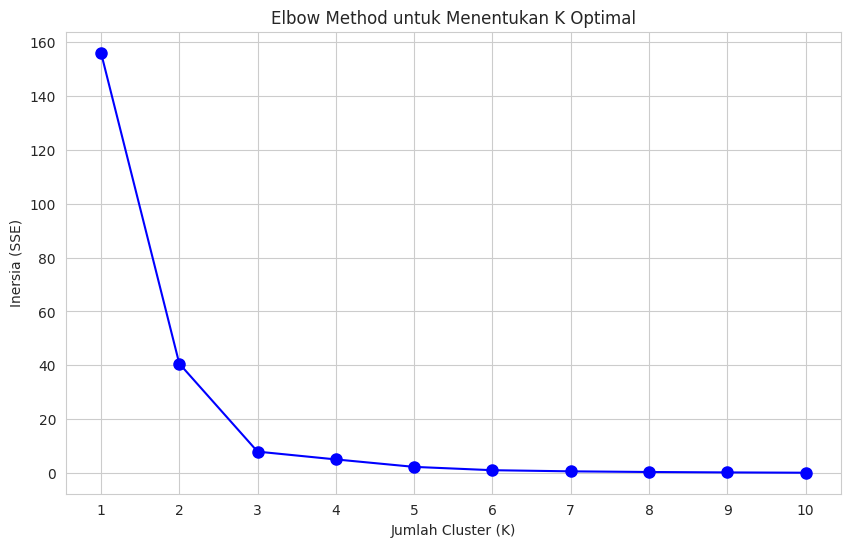

Interpretasi: Cari titik siku/lengkungan pada grafik.
Berdasarkan grafik, jika terjadi penurunan tajam lalu landai,
maka jumlah cluster optimal berada di titik tersebut.
Contoh: jika siku di K=3 atau K=4, maka gunakan K tersebut.


In [8]:
# ============================================
# CELL 7: MENENTUKAN JUMLAH CLUSTER DENGAN ELBOW METHOD
# ============================================
# Penjelasan: Mencari jumlah cluster optimal dengan melihat inersia (SSE).
# Titik siku (elbow) menunjukkan keseimbangan antara jumlah cluster dan inersia.

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(fitur_scaled)
    inertia.append(kmeans.inertia_)

# Plot grafik Elbow
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', markersize=8)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (SSE)')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Interpretasi (akan muncul di output)
print("Interpretasi: Cari titik siku/lengkungan pada grafik.")
print("Berdasarkan grafik, jika terjadi penurunan tajam lalu landai,")
print("maka jumlah cluster optimal berada di titik tersebut.")
print("Contoh: jika siku di K=3 atau K=4, maka gunakan K tersebut.")

In [9]:
# ============================================
# CELL 8: MEMBANGUN MODEL K-MEANS CLUSTERING
# ============================================
# Penjelasan: Menggunakan jumlah cluster terbaik dari Elbow Method.
# Di sini saya asumsikan K=3 (bisa Anda ubah sesuai hasil Elbow).

# Tentukan jumlah cluster terbaik (ganti angka ini jika elbow method menunjukkan K lain)
K_optimal = 3
print(f"Menggunakan K = {K_optimal} cluster berdasarkan Elbow Method.")

# Membangun model K-Means
kmeans_model = KMeans(n_clusters=K_optimal, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(fitur_scaled)

# Tambahkan kolom Cluster ke data asli (pivot table)
df_pivot_table['Cluster'] = cluster_labels

print("\n=== Data dengan Label Cluster (5 baris pertama) ===")
display(df_pivot_table.head())

Menggunakan K = 3 cluster berdasarkan Elbow Method.

=== Data dengan Label Cluster (5 baris pertama) ===


SUBJECT,LOCATION,BEEF,PIG,POULTRY,SHEEP,Cluster
0,ARG,1257.836258,208.084669,691.512764,28.788622,0
1,AUS,355.724010,279.881663,477.715845,140.178051,0
2,BRA,3484.221481,1296.015609,3529.160515,60.923994,0
3,BRICS,8807.482812,26275.555862,14502.921139,2471.656163,2
4,CAN,497.594890,405.756307,613.962227,17.531990,0


In [11]:
# ============================================
# CELL 9: MENAMPILKAN HASIL CLUSTERING
# ============================================
# Penjelasan: Melihat distribusi negara di setiap cluster.

print("=== Beberapa Data Hasil Clustering ===")
display(df_pivot_table[['LOCATION', 'Cluster'] + list(fitur_columns)].head(10))

print("\n=== Jumlah Negara per Cluster ===")
cluster_counts = df_pivot_table['Cluster'].value_counts().sort_index()
for cluster_id in sorted(cluster_counts.index):
    print(f"Cluster {cluster_id}: {cluster_counts[cluster_id]} negara")

=== Beberapa Data Hasil Clustering ===


SUBJECT,LOCATION,Cluster,BEEF,PIG,POULTRY,SHEEP
0,ARG,0,1257.836258,208.084669,691.512764,28.788622
1,AUS,0,355.724010,279.881663,477.715845,140.178051
2,BRA,0,3484.221481,1296.015609,3529.160515,60.923994
3,BRICS,2,8807.482812,26275.555862,14502.921139,2471.656163
4,CAN,0,497.594890,405.756307,613.962227,17.531990
5,CHE,0,89.691951,138.775795,64.191393,6.826957
6,CHL,0,208.138800,181.803173,291.937684,5.528543
7,CHN,2,2901.858199,23269.215887,7329.547986,1864.671812
8,COL,0,387.374680,152.741181,587.378636,5.310005
9,EGY,0,483.335785,1.001059,486.434822,62.151359



=== Jumlah Negara per Cluster ===
Cluster 0: 35 negara
Cluster 1: 1 negara
Cluster 2: 3 negara


In [12]:
# ============================================
# CELL 10: EVALUASI DENGAN SILHOUETTE SCORE
# ============================================
# Penjelasan: Mengukur seberapa mirip suatu objek dengan clusternya sendiri
# dibandingkan dengan cluster lain. Range: -1 (buruk) hingga 1 (sangat baik).

sil_score = silhouette_score(fitur_scaled, cluster_labels)
print(f"Silhouette Score untuk K={K_optimal}: {sil_score:.4f}")

# Interpretasi
if sil_score > 0.5:
    interpretasi = "Baik (struktur cluster kuat)"
elif sil_score > 0.25:
    interpretasi = "Cukup (struktur cluster sedang)"
else:
    interpretasi = "Lemah (struktur cluster tidak jelas)"

print(f"Interpretasi: {interpretasi}")
print("Silhouette Score mendekati 1 berarti cluster padat dan terpisah dengan baik.")

Silhouette Score untuk K=3: 0.8518
Interpretasi: Baik (struktur cluster kuat)
Silhouette Score mendekati 1 berarti cluster padat dan terpisah dengan baik.


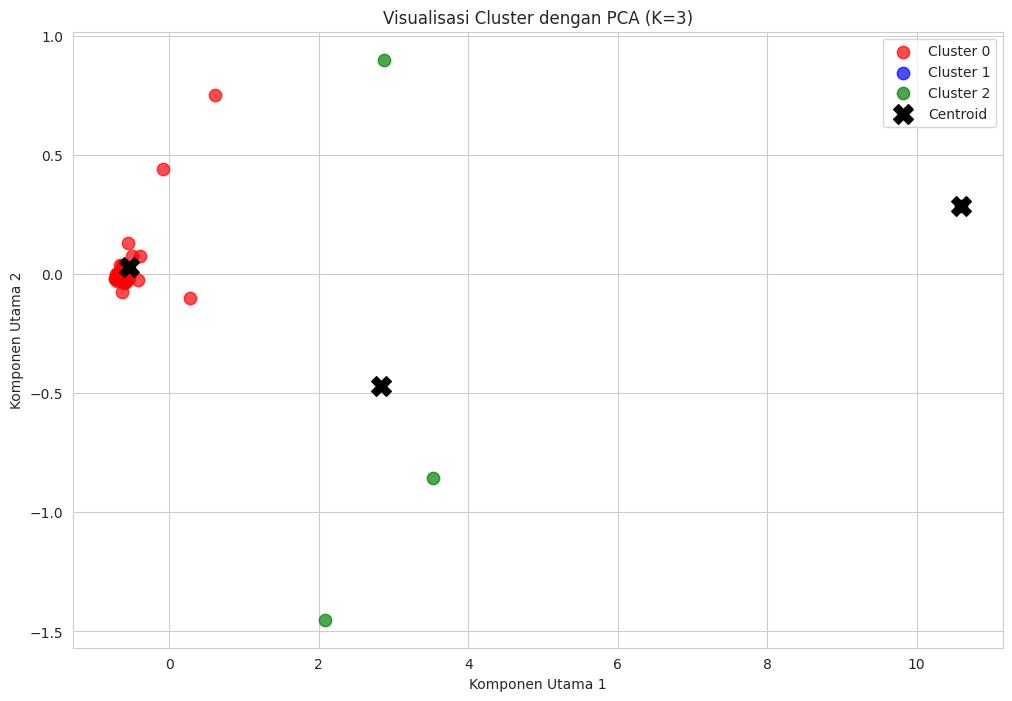

In [13]:
# ============================================
# CELL 11: VISUALISASI CLUSTER DENGAN PCA (2 DIMENSI)
# ============================================
# Penjelasan: Mereduksi dimensi fitur menjadi 2 komponen utama
# untuk memvisualisasikan cluster dalam bidang 2D.

pca = PCA(n_components=2)
fitur_pca = pca.fit_transform(fitur_scaled)

# Buat DataFrame untuk visualisasi
df_pca = pd.DataFrame(fitur_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels
df_pca['LOCATION'] = df_pivot_table['LOCATION']

# Scatter plot
plt.figure(figsize=(12, 8))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']

for cluster_id in range(K_optimal):
    subset = df_pca[df_pca['Cluster'] == cluster_id]
    plt.scatter(subset['PC1'], subset['PC2'],
                c=colors[cluster_id % len(colors)],
                label=f'Cluster {cluster_id}', alpha=0.7, s=80)

# Plot centroid dalam ruang PCA
centroids_pca = pca.transform(kmeans_model.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=200, label='Centroid')

plt.xlabel('Komponen Utama 1')
plt.ylabel('Komponen Utama 2')
plt.title(f'Visualisasi Cluster dengan PCA (K={K_optimal})')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# ============================================
# CELL 12: DAFTAR NEGARA PER CLUSTER
# ============================================

for cluster_id in sorted(df_pivot_table['Cluster'].unique()):
    negara_cluster = df_pivot_table[df_pivot_table['Cluster'] == cluster_id]['LOCATION'].tolist()

    print(f"\n=== Cluster {cluster_id} ({len(negara_cluster)} negara) ===")

    for negara in negara_cluster:
        print(f"- {negara}")


=== Cluster 0 (35 negara) ===
- ARG
- AUS
- BRA
- CAN
- CHE
- CHL
- COL
- EGY
- ETH
- EU27
- GBR
- IDN
- IND
- IRN
- ISR
- JPN
- KAZ
- KOR
- MEX
- MYS
- NGA
- NOR
- NZL
- PAK
- PER
- PHL
- PRY
- RUS
- SAU
- THA
- TUR
- UKR
- USA
- VNM
- ZAF

=== Cluster 1 (1 negara) ===
- WLD

=== Cluster 2 (3 negara) ===
- BRICS
- CHN
- OECD


=== Rata-rata Konsumsi per Jenis Daging per Cluster ===


SUBJECT,BEEF,PIG,POULTRY,SHEEP
Cluster,,,,
0,680.556822,663.904580,937.704490,76.690963
1,31063.248016,49060.657874,45673.381305,6351.286491
2,8058.976988,21896.072666,13235.902909,1772.949789


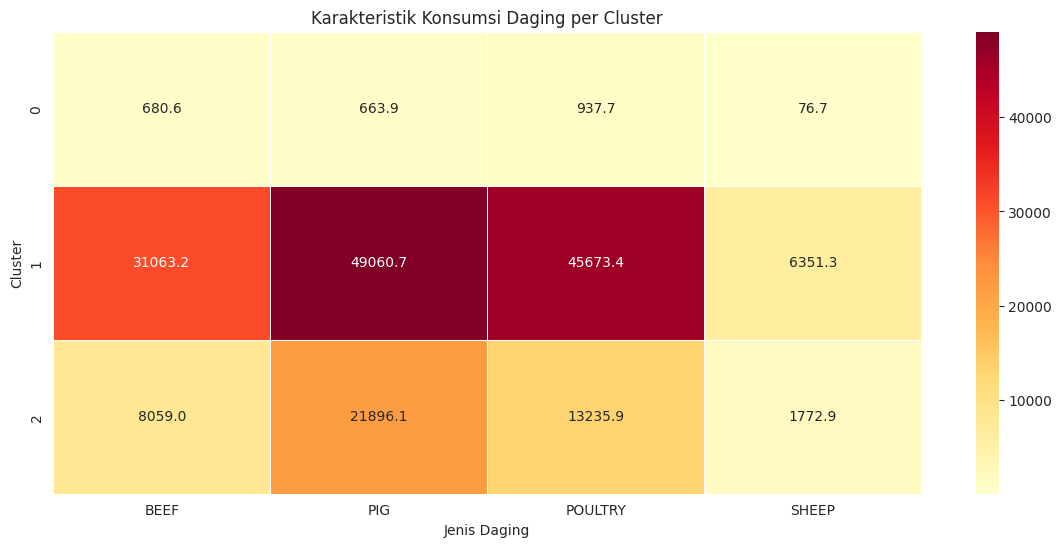


=== Interpretasi Karakteristik Cluster ===
Cluster 0: Konsumsi tertinggi pada POULTRY
Cluster 1: Konsumsi tertinggi pada PIG
Cluster 2: Konsumsi tertinggi pada PIG


In [17]:
# ============================================
# CELL 13: ANALISIS KARAKTERISTIK CLUSTER
# ============================================
# Penjelasan: Menghitung rata-rata konsumsi setiap jenis daging per cluster
# untuk memahami pola konsumsi masing-masing kelompok.

# Hitung rata-rata per cluster
fitur_columns_list = list(fitur_columns)
cluster_profiles = df_pivot_table.groupby('Cluster')[fitur_columns_list].mean()

print("=== Rata-rata Konsumsi per Jenis Daging per Cluster ===")
display(cluster_profiles)

# Visualisasi heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=0.5)
plt.title('Karakteristik Konsumsi Daging per Cluster')
plt.ylabel('Cluster')
plt.xlabel('Jenis Daging')
plt.show()

# Interpretasi
print("\n=== Interpretasi Karakteristik Cluster ===")
for cluster_id in cluster_profiles.index:
    max_daging = cluster_profiles.loc[cluster_id].idxmax()
    print(f"Cluster {cluster_id}: Konsumsi tertinggi pada {max_daging}")

In [22]:
# ============================================
# CELL 14: KESIMPULAN OTOMATIS
# ============================================
# Penjelasan: Menarik ringkasan akhir dari hasil clustering,
# mengelompokkan cluster berdasarkan tingkat konsumsi.

# Hitung total rata-rata konsumsi per cluster
cluster_profiles['Total_Rata'] = cluster_profiles.sum(axis=1)

ranking = cluster_profiles['Total_Rata'].rank(method='dense', ascending=False)

print("="*60)
print("KESIMPULAN AKHIR: PENGELOMPOKAN NEGARA BERDASARKAN POLA KONSUMSI DAGING")
print("="*60)

for cluster_id, row in cluster_profiles.sort_index().iterrows():

    if ranking[cluster_id] == 1:
        level = "TINGGI"
    elif ranking[cluster_id] == ranking.max():
        level = "RENDAH"
    else:
        level = "SEDANG"

    print(f"\nCluster {int(cluster_id)} (Konsumsi {level}):")
    print(f"  - Rata-rata total konsumsi: {row['Total_Rata']:.2f}")
    print(f"  - Jenis daging dominan: {row.drop('Total_Rata').idxmax()}")
    print(f"  - Jumlah negara: {len(df_pivot_table[df_pivot_table['Cluster']==cluster_id])}")

print("\n" + "="*60)
print("RINGKASAN:")
print(f"Jumlah cluster optimal: {K_optimal}")
print(f"Silhouette Score: {sil_score:.4f} ({interpretasi})")
print("Proyek berhasil mengelompokkan negara berdasarkan pola konsumsi daging.")
print("="*60)

KESIMPULAN AKHIR: PENGELOMPOKAN NEGARA BERDASARKAN POLA KONSUMSI DAGING

Cluster 0 (Konsumsi RENDAH):
  - Rata-rata total konsumsi: 11794.28
  - Jenis daging dominan: POULTRY
  - Jumlah negara: 35

Cluster 1 (Konsumsi TINGGI):
  - Rata-rata total konsumsi: 660742.87
  - Jenis daging dominan: PIG
  - Jumlah negara: 1

Cluster 2 (Konsumsi SEDANG):
  - Rata-rata total konsumsi: 224819.51
  - Jenis daging dominan: PIG
  - Jumlah negara: 3

RINGKASAN:
Jumlah cluster optimal: 3
Silhouette Score: 0.8518 (Baik (struktur cluster kuat))
Proyek berhasil mengelompokkan negara berdasarkan pola konsumsi daging.
